## Simple Linear Regression Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [3]:
df.shape

(23, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [5]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


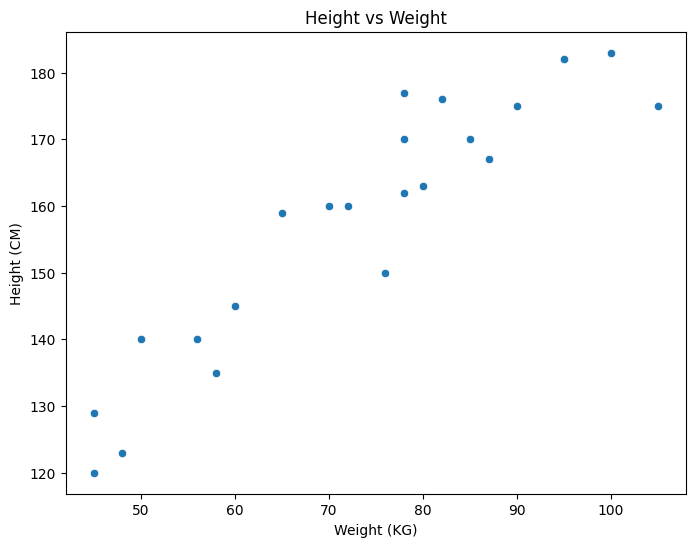

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Weight', y='Height', data=df)
plt.title('Height vs Weight')
plt.xlabel('Weight (KG)')
plt.ylabel('Height (CM)')
plt.show()

In [7]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [8]:
x = df[['Weight']]   ## INdependent variable
y = df['Height']     ## Dependent variable

In [9]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [10]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((17, 1), (6, 1), (17,), (6,))

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [12]:
x_train_scaled

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [13]:
x_test_scaled

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [ ]:
linereg = LinearRegression()
linereg.fit(x_train_scaled, y_train)

LinearRegression()

In [15]:
linereg.intercept_, linereg.coef_

(np.float64(156.47058823529412), array([17.2982057]))

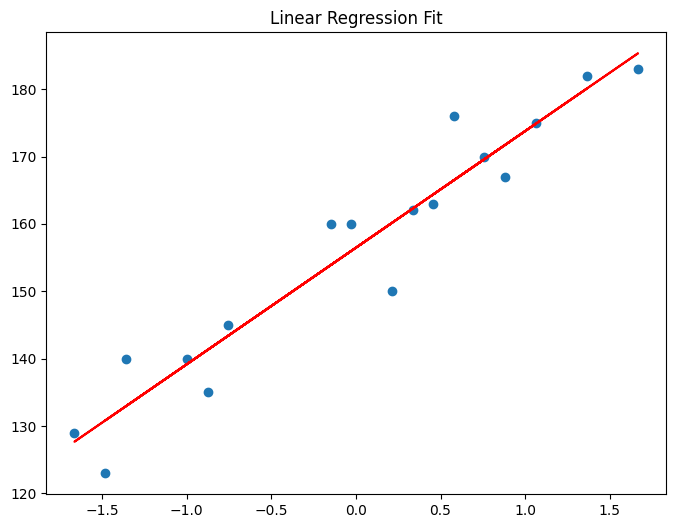

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(x_train_scaled, y_train)
plt.plot(x_train_scaled, linereg.predict(x_train_scaled), color='red')
plt.title('Linear Regression Fit')
plt.show()

### prediction of train data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_train =156.5 + 17.03(X_train)
          
### prediction of test data
1. predicted height output= intercept +coef_(Weights)
2. y_pred_test =156.5 + 17.03(X_test)

In [21]:
y_pred_test = linereg.predict(x_test_scaled)

In [23]:
y_pred_test, y_test

(array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
        148.64197186, 190.55897293]),
 15    177
 9     170
 0     120
 8     182
 17    159
 12    175
 Name: Height, dtype: int64)

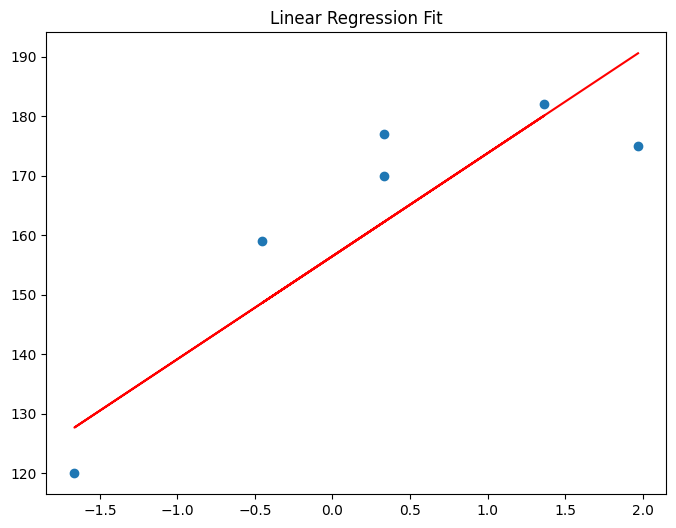

In [24]:
plt.figure(figsize=(8, 6))
plt.scatter(x_test_scaled, y_test)
plt.plot(x_test_scaled, y_pred_test, color='red')
plt.title('Linear Regression Fit')
plt.show()

### Performance Metrics

### MSE,MAE,RMSE
### R square and adjusted R square

## R square 
Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares

In [25]:
## Performance Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')   
print(f'R^2 Score: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 114.84069295228699
Root Mean Squared Error: 10.716374991212605
R^2 Score: 0.7360826717981276
Mean Absolute Error: 9.66512588679501


## Adjusted R Square

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [28]:
#display adjusted R-squared
1 - (1-r2)*(len(y_test)-1)/(len(y_test)-x_test_scaled.shape[1]-1)

0.6701033397476595

In [30]:
linereg

LinearRegression()

In [33]:
## New Prediction
scaled_weight = scaler.transform([[70]])  # Example weight of 70 KG
predicted_height = linereg.predict(scaled_weight)
print(f'Predicted Height for 70 KG: {predicted_height[0]} CM')

Predicted Height for 70 KG: 153.8815969929395 CM


e:\Work\OneDrive - Rapifuzz Private Limited\Desktop\Ayush\Data_Science\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


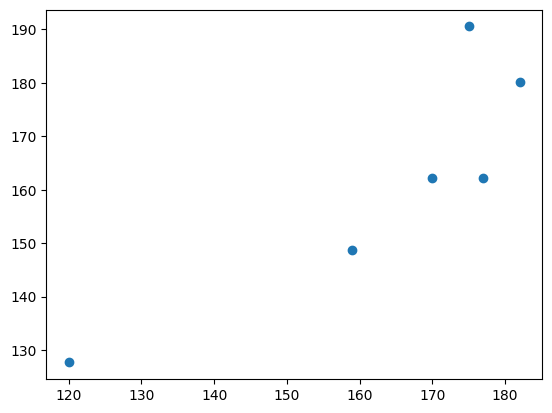

In [ ]:
## Assumptions
## plot a scatter plot for the prediction
plt.scatter(y_test,y_pred_test)

In [ ]:
## Residuals
residuals = y_test - y_pred_test
print(f'Residuals: {residuals}')

Residuals: 15    14.735003
9      7.735003
0     -7.683471
8      1.920277
17    10.358028
12   -15.558973
Name: Height, dtype: float64


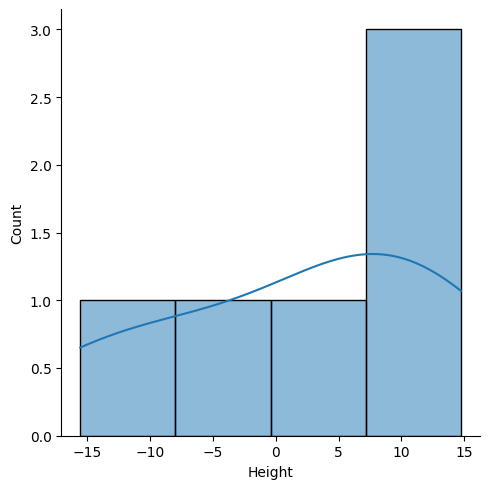

In [37]:
sns.displot(residuals, kde=True)
plt.show()

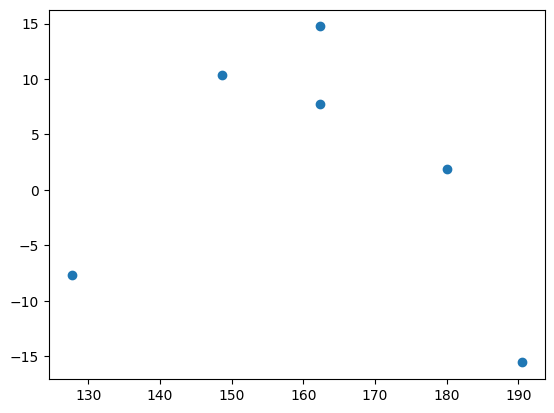

In [40]:
## Scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(y_pred_test,residuals)
plt.show()